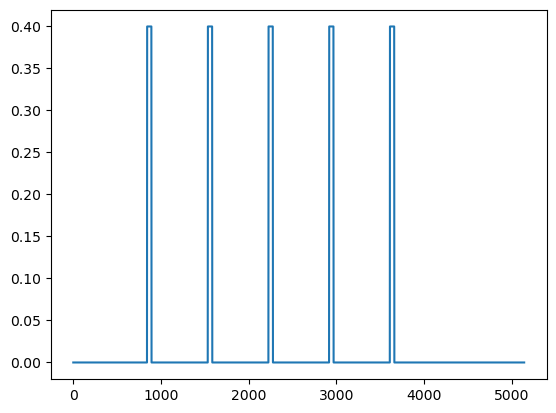

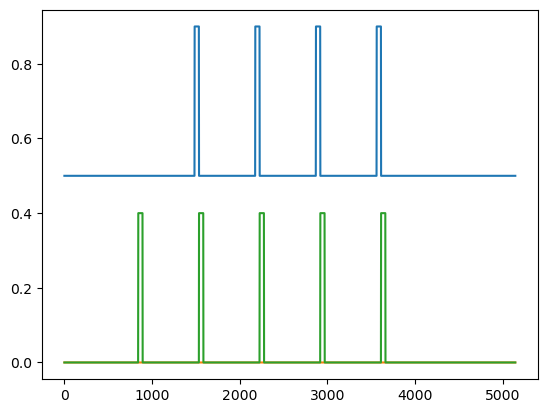

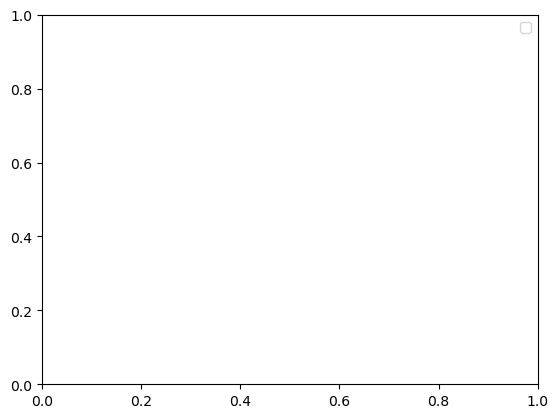

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

def random_pulses(dt, showplots = 0):
    n_events = 5
    hint = 'nohint'
    #period = 0.5+.15*2*(np.random.uniform()-.5);
    period = np.random.uniform()
    ITIb = 0.7 #min. ITI time
    ITIl = 2.0 #mean ITI time
    ITI = ITIb + np.random.exponential(ITIl) #compute ITI for that trial
    fin, fout, fhint = trial_pulse_prediction(dt, period, n_events, ITI, hint)
    if showplots == 1:
        plt.figure()
        plt.plot(fout)
        plt.plot(fhint)
        plt.plot(fin)
        plt.show()
        plt.legend(['Target','Hints','Input'])
    return fin, fout, fhint

def trial_pulse_prediction(dt, period, n_events, ITI, hint):
    output_offset = -0.5
    pulse_width = 0.05 # 0.05
    pulse_height = 0.02 / pulse_width
    output_timeshift = -pulse_width
    pulse_samples = np.round(pulse_width/dt).astype('int')
    
    n_timepoints = np.round((period*n_events+ITI)/dt).astype('int')
    
    
    timepoints = np.arange(0, n_timepoints)*dt

    
    fin = np.zeros((n_timepoints,1))
    fout = np.zeros((n_timepoints,1))
    
    fin[ np.mod(timepoints- ITI/2, period) < pulse_width ,0] = pulse_height
    
    fin[ timepoints < ITI/2 ,0] = 0
    fin[ timepoints > ITI/2 + period*n_events,0] = 0
    
    a = np.where(fin != 0)
    
    a = np.array_split(a[0],5)
    
    
    #concatenate with time delay
    idx = a[4][0]
    #fin = np.concatenate((fin[:idx], np.zeros((200, 1)), fin[idx:]), axis=0)
    #fin = fin[:-200]
    plt.plot(fin)
    
    fout = fin - output_offset
    
    fout[timepoints < ITI/2+pulse_width,0] = -output_offset
    fout[0:-1-pulse_samples]=fout[pulse_samples:-1]
    
    # desired output signals and hint signals
    fhint = np.zeros(fin.shape)
    
    
    
    return fin, fout, fhint

random_pulses(dt=0.001,showplots=1)


def specific_pulse(dt, showplots = 0, period = 0.4):
    n_events = 5
    hint = 'nohint'
    #period = 0.7 
    ITIb = 0.7 #min. ITI time
    ITIl = 2.0 #mean ITI time
    #print(period)
    ITI = ITIb + np.random.exponential(ITIl) #compute ITI for that trial
    fin, fout, fhint = trial_pulse_prediction(dt, period, n_events, ITI, hint)
    if showplots == 1:
        plt.figure()
        plt.plot(fout)
        plt.plot(fhint)
        plt.plot(fin)
        plt.show()
        plt.legend(['Target','Hints','Input'])
    return fin, fout, fhint


Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is [0.095] seconds early
The width of the predicted pulse at half-max is 100.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is [0.097] seconds early
The width of the predicted pulse at half-max is 200.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is [0.211] seconds early
The width of the predicted pulse at half-max is 280.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is [0.1] seconds early
The width of the predicted pulse at half-max is 132.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is [0.072] seconds early
The width of the predicted pulse at half-max is 160.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is [0.105] seconds early
The width of the predicted pulse at half-max is 1

C:\Users\Manav\AppData\Local\Temp\ipykernel_14644\2312346085.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


....
Testing: 10 trials
..........
The predicted pulse peak is [0.073] seconds early
The width of the predicted pulse at half-max is 180.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is [0.021] seconds early
The width of the predicted pulse at half-max is 282.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is [0.049] seconds early
The width of the predicted pulse at half-max is 157.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is [0.07] seconds early
The width of the predicted pulse at half-max is 130.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is [0.05] seconds early
The width of the predicted pulse at half-max is 172.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is [0.114] seconds early
The width of the predicted pulse at half-max is 165.0% the siz

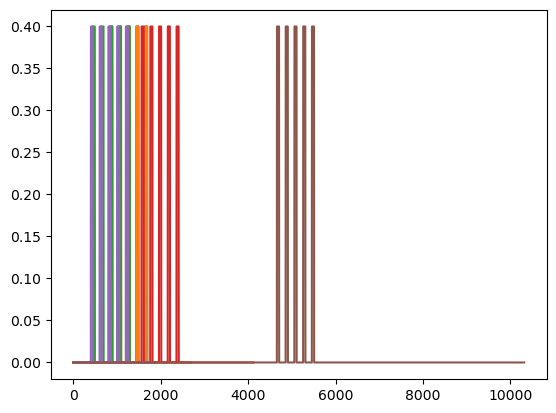

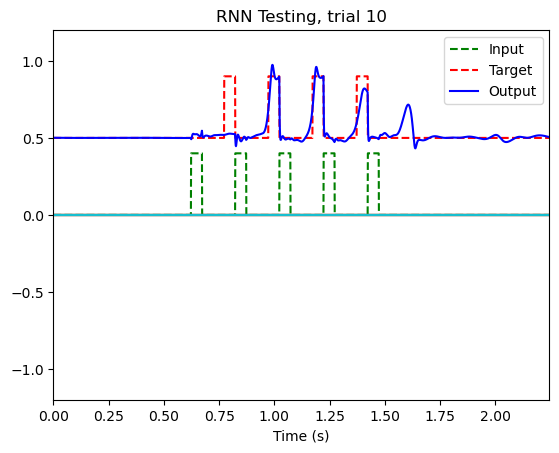

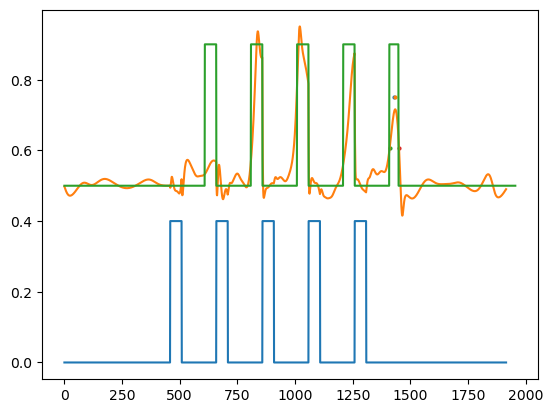

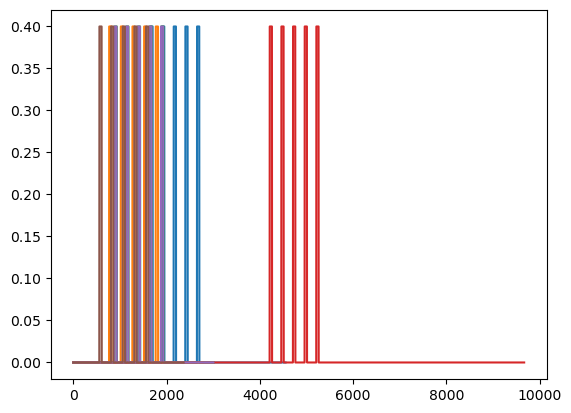

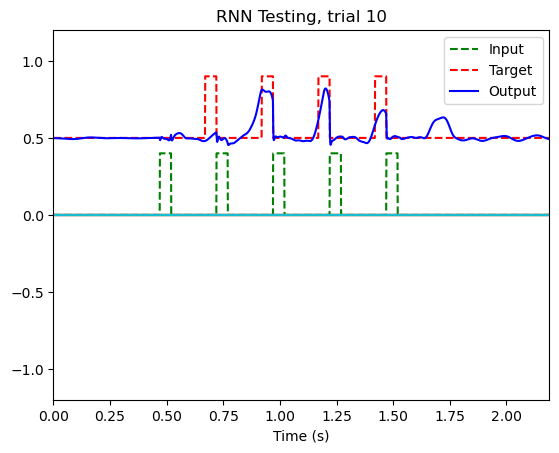

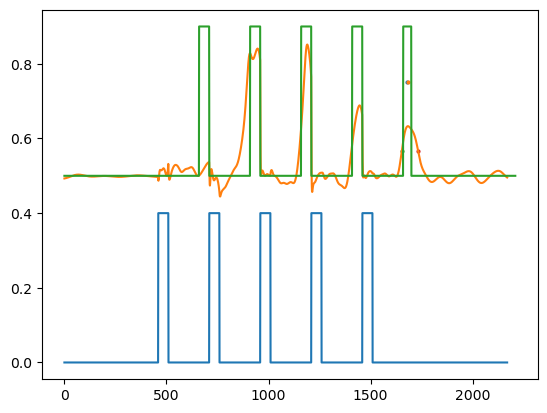

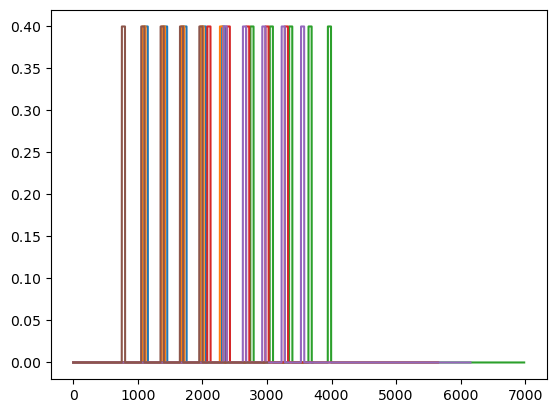

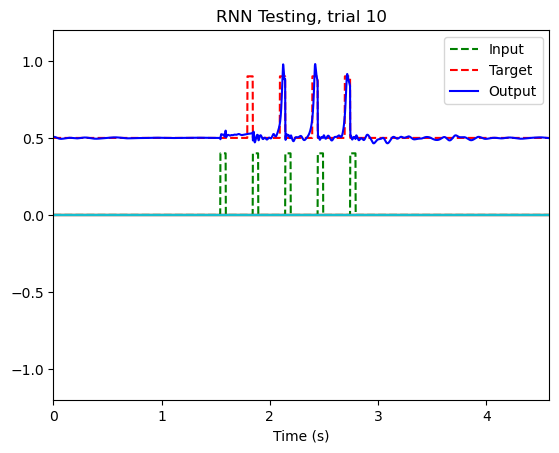

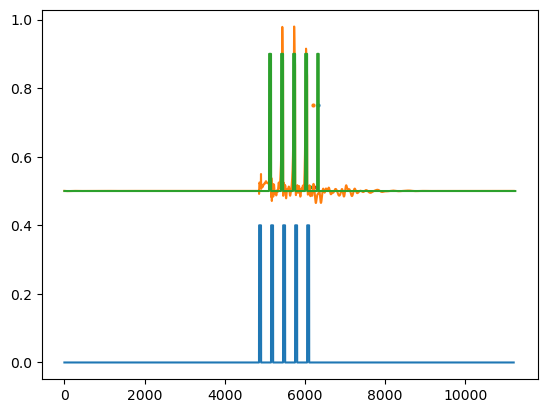

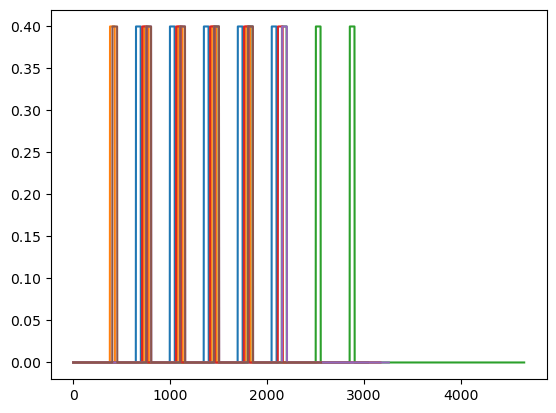

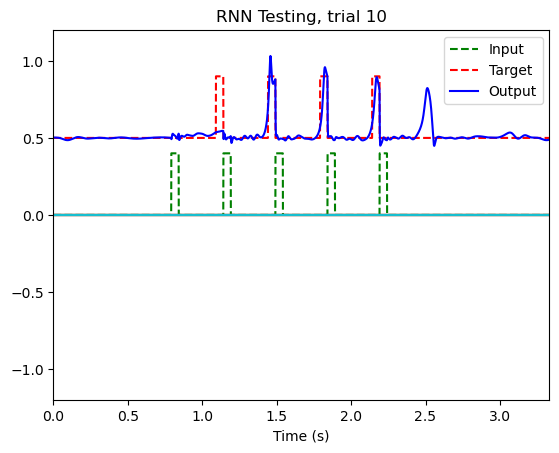

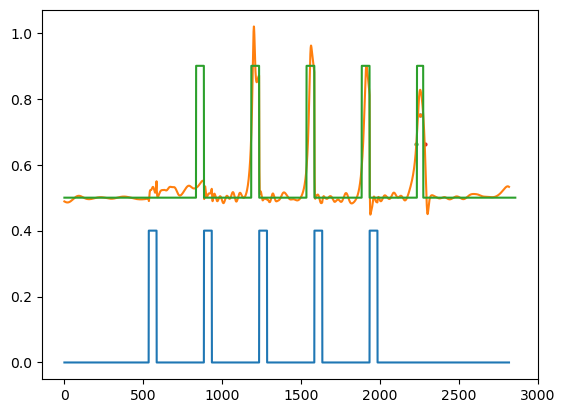

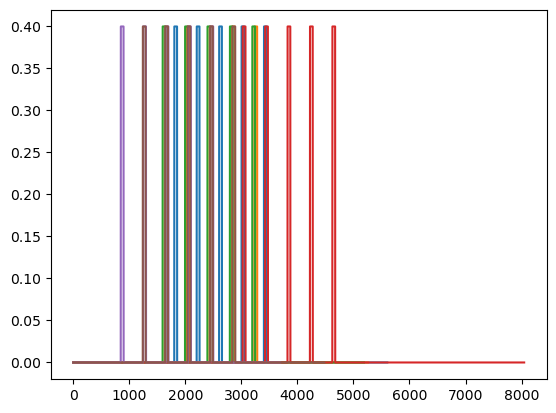

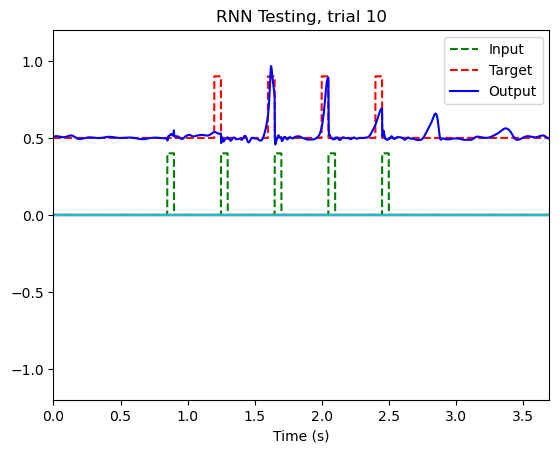

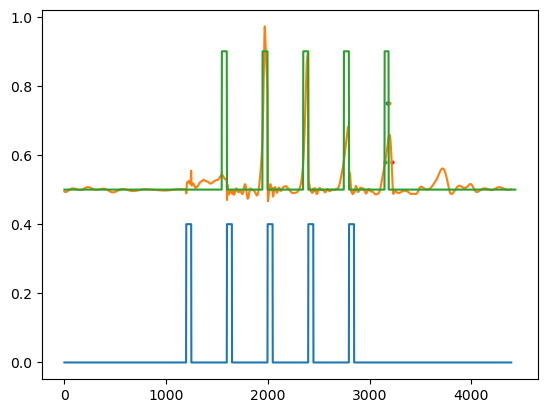

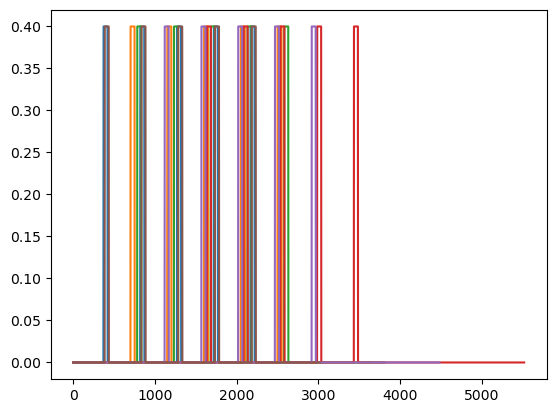

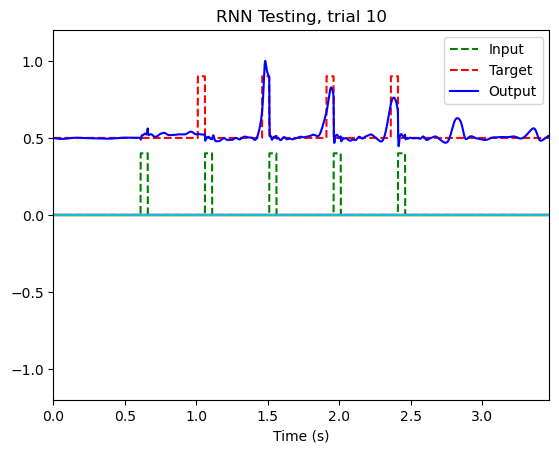

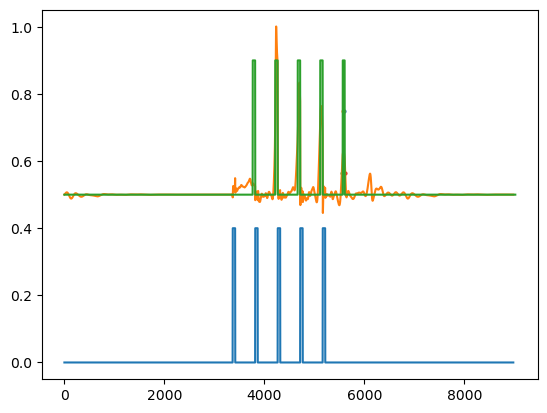

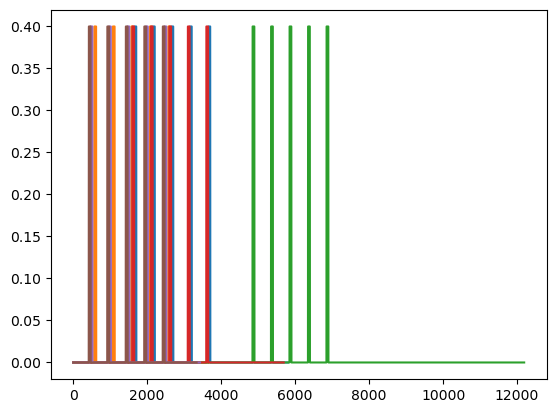

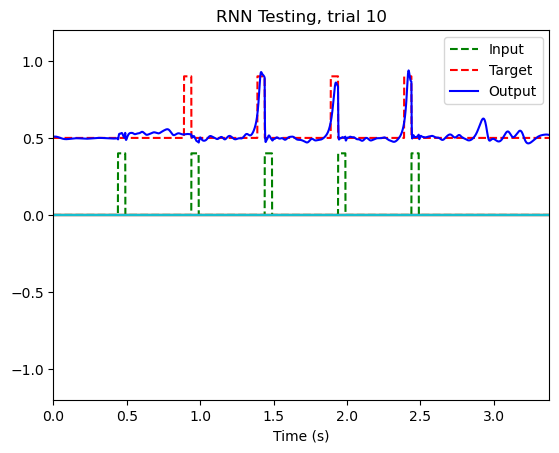

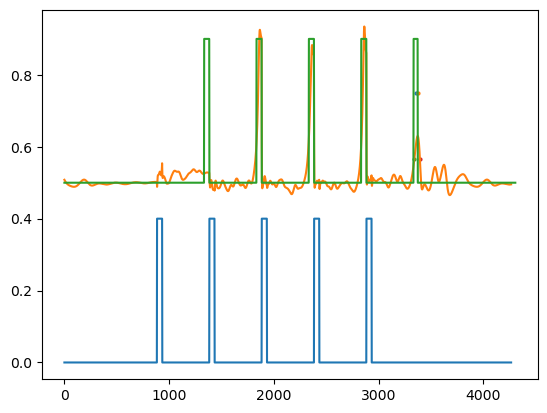

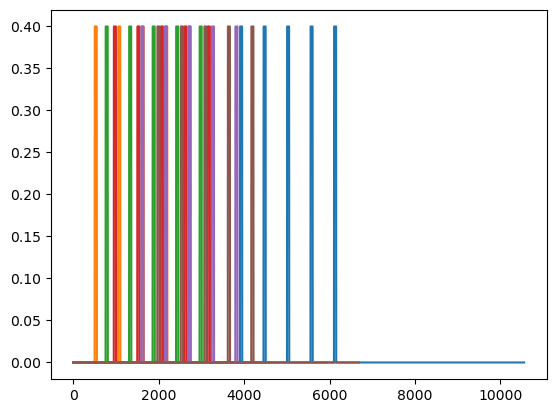

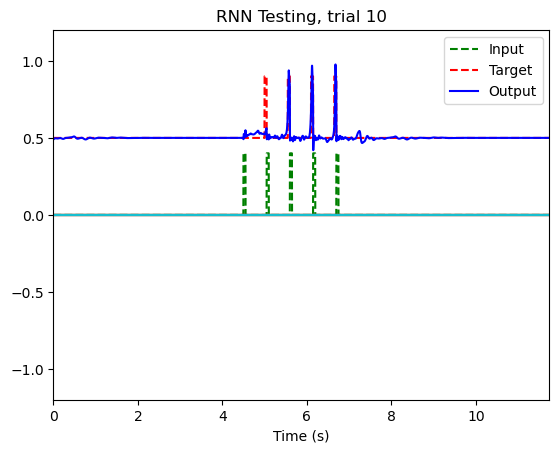

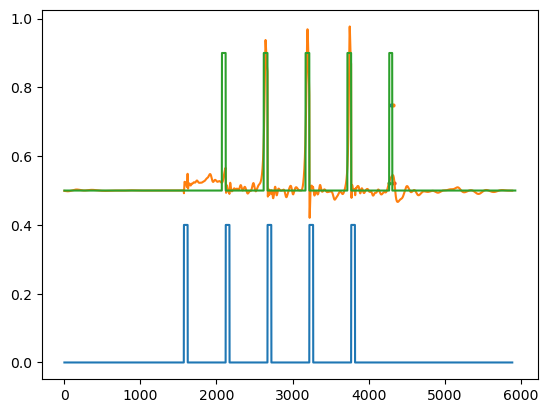

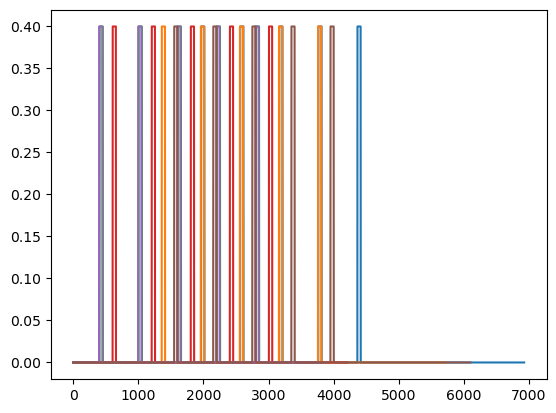

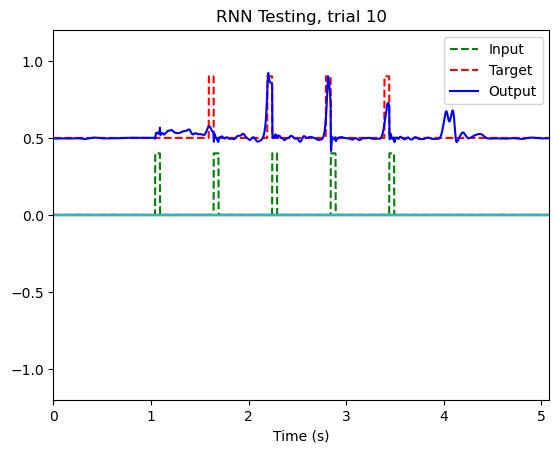

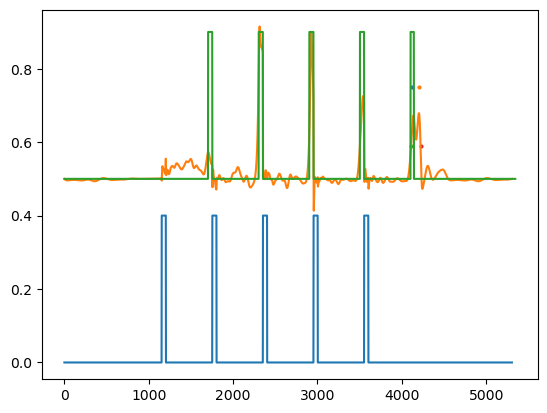

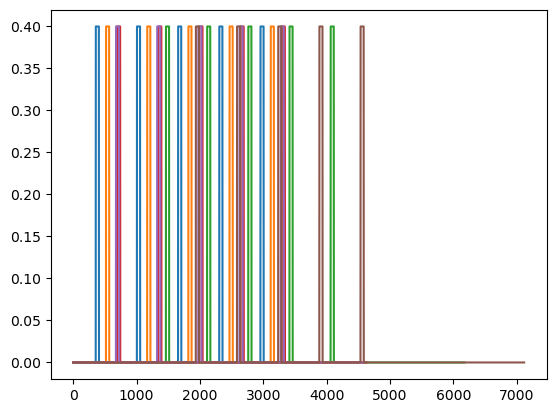

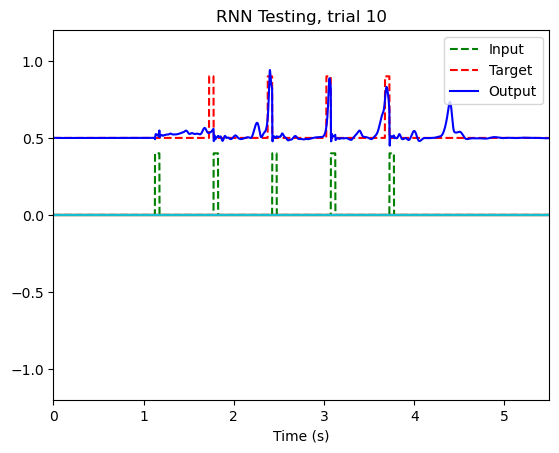

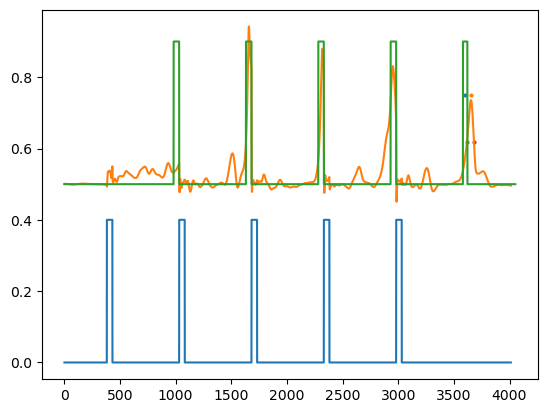

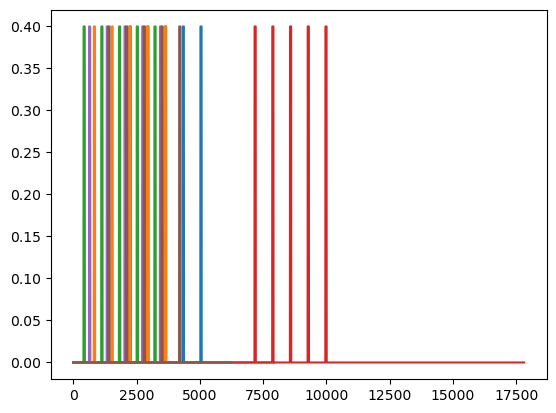

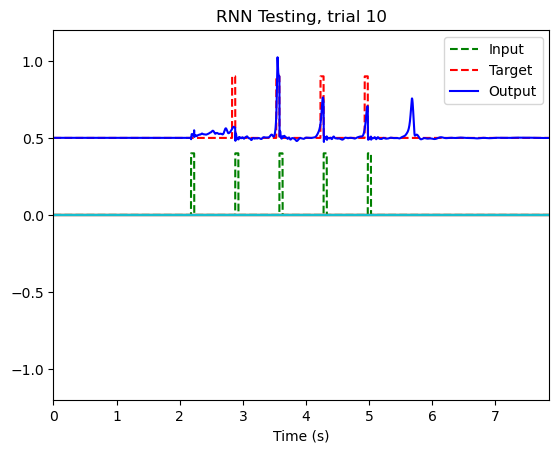

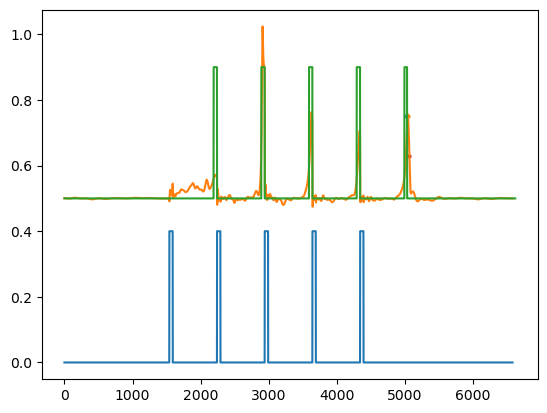

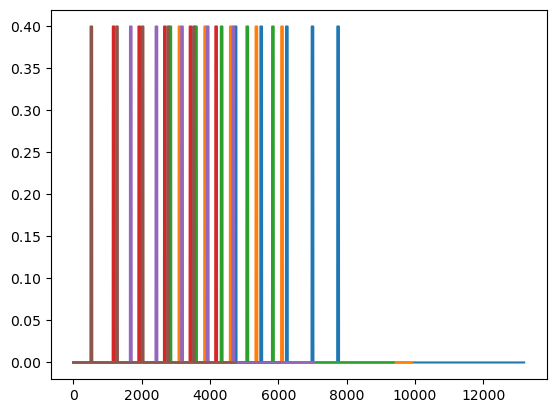

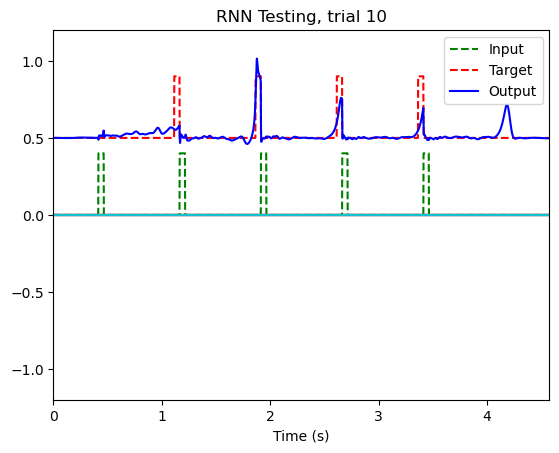

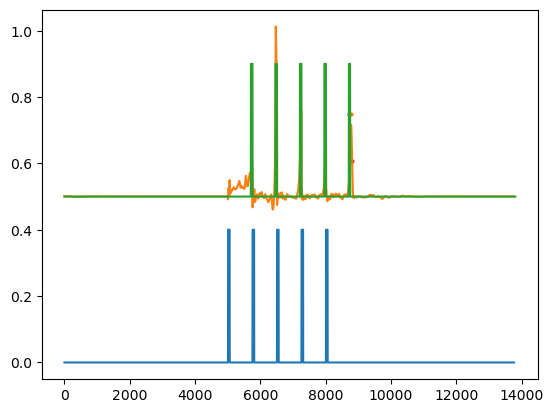

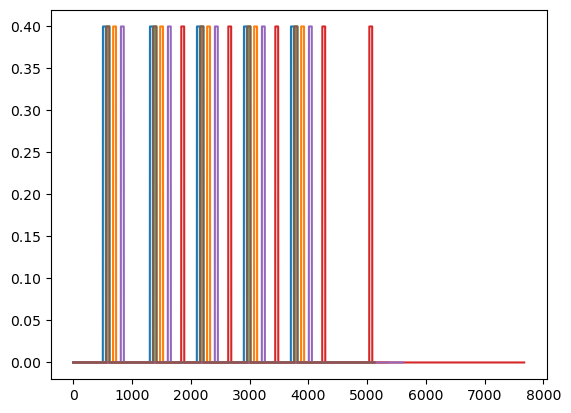

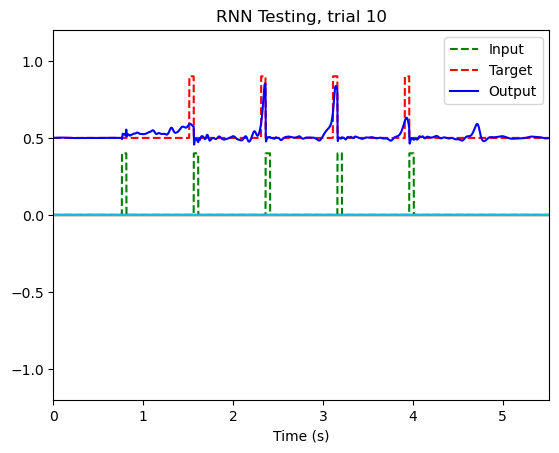

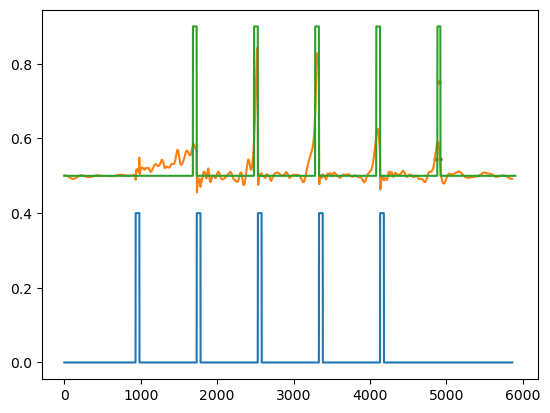

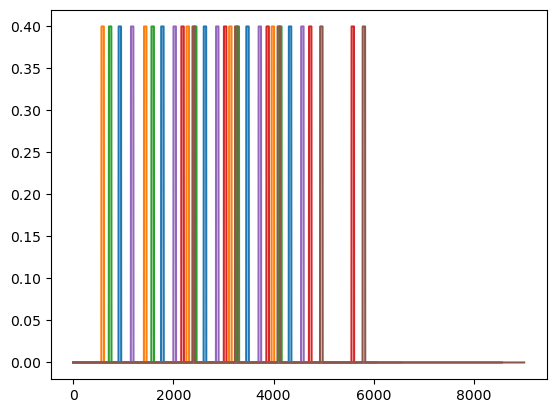

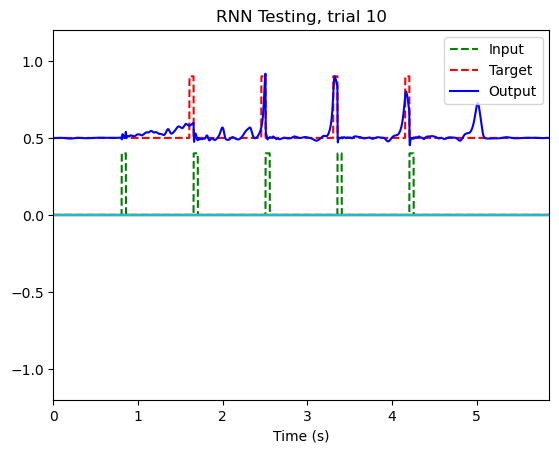

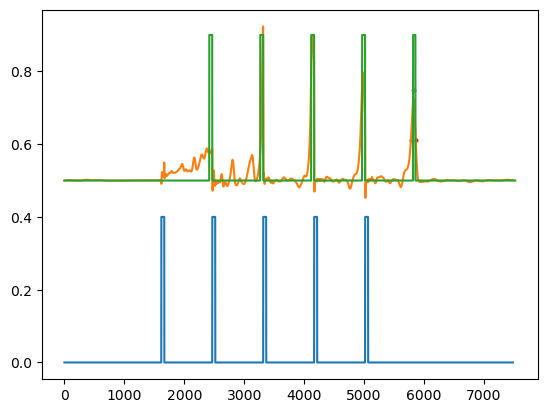

<Figure size 640x480 with 0 Axes>

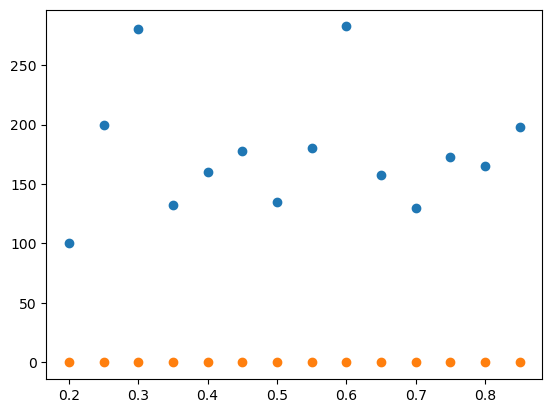

In [9]:
import pickle
import FF_Demo
import numpy as np

rnn = pickle.load(open("model16-2000-full-period-20-20-0.5",'rb'))

half_max_width = [] 
position_error = []

range_array = np.arange(0.2,0.9,0.05)

for item in range_array:
    x = rnn.test(specific_pulse, period = item)
    plt.figure()

    ftarg = x[0][1]; fout = x[0][2]

    a = np.where(ftarg == np.max(ftarg))
    a = np.array_split(a[0],5)

    idx = a[4][0] + abs(a[4][0] -  a[3][0])
    ftarg = np.concatenate((ftarg[:idx], np.full_like(np.zeros((40, 1)),0.9), ftarg[idx:]), axis=0)

    plt.plot(x[0][0])
    plt.plot(fout)
    plt.plot(ftarg)

    max_val = np.max(fout[idx-100:idx+100])

    max_out_near_predict = np.where(fout[idx-100:idx+100] == max_val)
    idx2 = max_out_near_predict[0][0]+ idx-100
    #print(np.max(fout[idx-200:idx+200]))
    plt.scatter(idx+20, 0.75,4)
    plt.scatter(idx - 100 + max_out_near_predict[0],0.75,4)
    time_from_target = 0.001*((idx-200+max_out_near_predict[0])-(idx+20))

    if time_from_target < 0: 
        print(f"The predicted pulse peak is {abs(time_from_target)} seconds early")
    else:
        print(f"The predicted pulse peak is {time_from_target} seconds late")
        
    position_error.append(time_from_target)
    
    pulse_left = idx2 -100 + np.abs(fout[idx2-100:idx2] - (0.25+max_val/2)).argmin()
    pulse_right = idx2 + np.abs(fout[idx2:idx2+100] - (0.25+max_val/2)).argmin()

    plt.scatter(pulse_left, 0.25+max_val/2,4)
    plt.scatter(pulse_right, 0.25+max_val/2,4)

    print(f"The width of the predicted pulse at half-max is {100*abs(pulse_left-pulse_right)/40}% the size of input")

    half_max_width.append(100*abs(pulse_left-pulse_right)/40)
    plt.figure()
    #plt.close()


plt.figure()
plt.scatter(range_array, half_max_width)
plt.scatter(range_array, position_error)
plt.show()
#print(error_to_plot)

## 

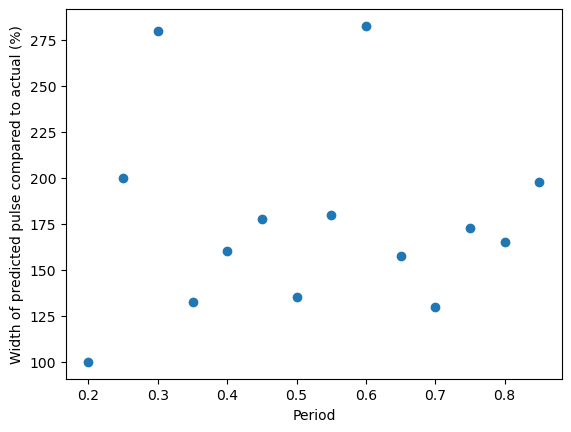

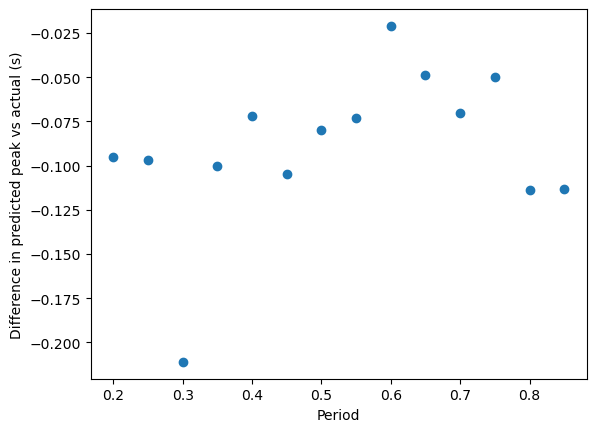

In [12]:
plt.figure()
plt.scatter(np.arange(0.2,0.9,0.05), half_max_width)
plt.ylabel("Width of predicted pulse compared to actual (%)")
plt.xlabel("Period")
plt.figure()
plt.ylabel("Difference in predicted peak vs actual (s)")
plt.xlabel("Period")
plt.scatter(np.arange(0.2,0.9,0.05), position_error)
plt.show()
#print(error_to_plot)